In [1]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: /Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip


In [2]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns; sns.set()
from sklearn import datasets, model_selection, preprocessing
import tensorflow as tf
# Wenn tensorflow noch nicht installiert ist, führe folgende Zeile in einer neuen Zelle aus: !pip install tensorflow (eventuell muss numpy geupdatet werden)
%matplotlib inline

2025-11-20 15:34:55.432065: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Users/alimounir/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


# Neuronale Netze
![](neural_network_small.png)
Bild aus: https://de.wikipedia.org/wiki/Datei:Neural_network.svg

Ein künstliches neuronales Netz setzt sich aus vielen einzelnen künstlichen Neuronen zusammen. Diese orientieren sich lose an biologischen Neuronen. Ein einzelnes Neuron ist durch eine Aktivierungsfunktion $f:\mathbb{R}\rightarrow\mathbb{R}$, einen Gewichtsvektor $w\in\mathbb{R}^{d_{in}}$ der Eingangsdimension $d_{in}\in\mathbb{N}$ und einen Bias $b\in\mathbb{R}$ parametrisiert.

Die Ausgabe des künstlichen Neurons berechnet sich dann für eine Eingabe $x\in\mathbb{R}^{d_{in}}$ als:
$f\left( x \cdot w^T + b\right) = f\left( \sum_{i=1}^{d_{in}} x_i w_i + b \right)$.

![](single_neuron.png)

Bild aus: https://de.wikipedia.org/wiki/Datei:NeuronModel_deutsch.svg
            
Bekannte Aktivierungsfunktionen sind z.B.
* die Heavyside Aktivierungsfunktion $x \mapsto \begin{cases} 1 \quad \text{fuer } x \geq 0 \\ 0 \quad\text{sonst}\end{cases}$
* die ReLU Aktivierungsfunktion $x \mapsto \begin{cases} x \quad \text{fuer } x \geq 0 \\ 0 \quad\text{sonst}\end{cases}$
* die Sigmoid Aktivierungsfunktion $x \mapsto \frac{1}{1 + e^{-x}}$
* die Tangens Hyperbolicus Aktivierungsfunktion $x \mapsto tanh(x) = 1 - \frac{2}{e^{2x} + 1}$.

Desweiteren gibt es noch die Softmax-Aktivierungsfunktion. Die Ausgabe der Softmax- und Sigmoidfunktion ist stets im Intervall $[0,1]$ und kann damit als Wahrscheinlichkeit aufgefasst werden. Die Softmax-Aktivierungsfunktion wird für Multiclass Klassifikationsprobleme verwendet und wird auf einem Vektor, nicht auf einem einzelnen Wert definiert (in diesem Setting hat das neuronale Netz nicht ein Ausgabeneuron, sondern so viele, wie es Klassen gibt - die softmax Aktivierungsfunktion wird auf die Ausgabe angewandt und wandelt diese in einen Wahrscheinlichkeitsvektor mit den Wahrscheinlichkeiten für die einzelnen Klassen um). Die Funktion ist für $n\in\mathbb{N}$ beliebig definiert durch: $\mathbb{R}^n \ni x \mapsto  \begin{pmatrix}
\exp(x_1) / \exp\left(\sum_{i=1}^n x_i\right) \\
\vdots \\
\exp(x_n) / \exp\left(\sum_{i=1}^n x_i\right)
 \end{pmatrix}\in\mathbb{R}^n$.

## Aufgabe 1: Aktivierungsfunktionen
* Schreibe eine Funktion heavysideNeuron mit dem Interface:
```python
def heavysideNeuron(x, params):        
    # return f(x * weights^T + bias)
```
wobei `params` ein Dictionary mit Gewichten (`weights`) und Bias (`bias`) des Neurons ist.

* Initialisiere eine Variable `params` mit `weights` `[1, 2, 0]` und `bias` `-1`.
* Teste ob `heavysideNeuron` die folgenden assert Statements erfüllt.
```python
assert heavysideNeuron(np.array([1, 1, 0]), params) == 1
assert heavysideNeuron(np.array([5, 7, 0]), params) == 1
assert heavysideNeuron(np.array([0, 0.4, 1]), params) == 0
assert heavysideNeuron(np.array([-10, 4, 10]), params) == 0
print("Well done!")
```

Hinweis: assert prüft eine Bedingung ab. Ist diese nicht erfüllt, wird ein Fehler ("AssertionError") ausgelöst. Ist sie erfüllt, läuft der Python Code weiter. 

In [3]:
def heavysideNeuron(x, params):

    weights = params['weights']
    bias = params['bias']
    
    weighted_sum = np.dot(x, weights) + bias
    
    if weighted_sum >= 0:
        return 1
    else:
        return 0

In [4]:
params = {
    'weights': np.array([1, 2, 0]),
    'bias': -1
}

In [5]:
assert heavysideNeuron(np.array([1, 1, 0]), params) == 1
assert heavysideNeuron(np.array([5, 7, 0]), params) == 1
assert heavysideNeuron(np.array([0, 0.4, 1]), params) == 0
assert heavysideNeuron(np.array([-10, 4, 10]), params) == 0
print("Well done!")

Well done!


* Oben haben wir die Aktivierungsfunktionen `relu`, `sigmoid` und `tanh` definiert. Programmiere diese als eine Python-Funktion, die ein `np.array` erhält und eines mit der gleichen Länge zurückgibt. In der Funktion soll nun die jeweilige Aktivierungsfunktion auf jedes Element in dem Array angewendet werden.
* Plotte die gerade definierten Aktivierungsfunktionen auf dem Interval `[-4, 4]`.
* Was für Unterschiede sind zu erkennen? Was für Auswirkungen könnten diese haben?

In [6]:
def heavyside(x):
    return np.where(x >= 0, 1, 0)
        
def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def tanh_formel(x):
    return 1 - (2 / (1 + np.exp(2 * x)))

In [7]:
xs = np.linspace(-4, 4, 100)
ys_heavyside = heavyside(xs)
ys_relu = relu(xs)
ys_sigmoid = sigmoid(xs)
ys_tanh = tanh(xs)

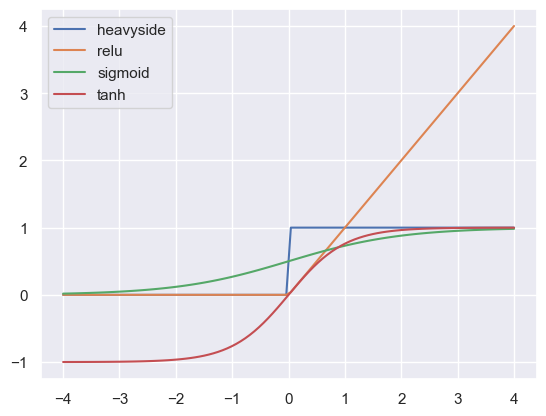

In [8]:
plt.plot(xs, ys_heavyside, label='heavyside')
plt.plot(xs, ys_relu, label='relu')
plt.plot(xs, ys_sigmoid, label='sigmoid')
plt.plot(xs, ys_tanh, label='tanh')
plt.legend(loc='upper left')

Optional:
- Plotte die Ableitungen der obigen Aktivierungsfunktionen.
- Was für Unterschiede sind zu erkennen? Was für Auswirkungen könnten diese haben? (insbesondere im Kontext von Gradient Descent)

In [9]:
def heavyside_p(x):
    return np.zeros_like(x)
    
def relu_p(x):
    return np.where(x > 0, 1, 0)

def sigmoid_p(x):
    return sigmoid(x) * (1 - sigmoid(x))

def tanh_p(x):
    return 1 - np.tanh(x)**2

In [10]:
xs = np.linspace(-4, 4, 100)
ys_heavyside_p = heavyside_p(xs)
ys_relu_p = relu_p(xs)
ys_sigmoid_p = sigmoid_p(xs)
ys_tanh_p = tanh_p(xs)

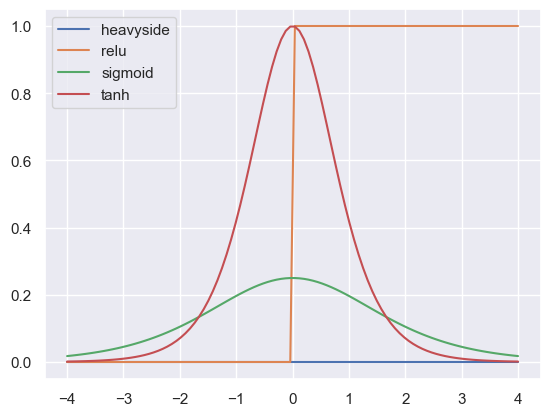

In [11]:
plt.plot(xs, ys_heavyside_p, label='heavyside')
plt.plot(xs, ys_relu_p, label='relu')
plt.plot(xs, ys_sigmoid_p, label='sigmoid')
plt.plot(xs, ys_tanh_p, label='tanh')
plt.legend(loc='upper left')

## Aufgabe 2: Simple Layer

![](multi_layer_network.png)

Bild aus: https://de.wikipedia.org/w/index.php?title=Datei:Multi-Layer_Neural_Network-Vector.svg

Die Neuronen eines neuronalen Netzes sind hintereinander in Schichten angeordnet. Eine Schicht eines neuronalen Netzes setzt sich aus mehreren Neuronen zusammen. Das Berechnen der Ausgaben der einzelnen Neuronen lässt sich gut mittels einer Matrixmultiplikation parallelisieren, da gilt:

Sei eine Schicht mit $n\in\mathbb{N}$ Neuronen, Aktivierungsfunktion $f$ und Eingangsdimension $d_{in}$ gegeben. Jedes Neuron (also für $i=1,\ldots,n$) habe Gewichtvektoren $w^i\in\mathbb{R}^{d_{in}}$ und bias $b^i\in\mathbb{R}$. 

Es sei $W = 
\begin{pmatrix}
w^1_1 & \ldots & w^1_{d_{in}} \\
\vdots & \ldots &\vdots \\
w^n_1 & \ldots & w^n_{d_{in}} 
 \end{pmatrix} \in\mathbb{R}^{n\times d_{in}}$
 und $B = 
\begin{pmatrix}
b^1 \\
\vdots \\
b^n
 \end{pmatrix}\in\mathbb{R}^n$
 
 
die Gesamtgewichtsmatrix bzw. der Biasvektor. Dann gilt für die Ausgabe $z^i$ des $i$-ten Neurons:
$z^i = f\left(\left( x W^T + B\right)_i\right)$ mit $x\in\mathbb{R}^{d_{in}}$.

Im folgenden Codeausschnitt ist beispielhaft eine einzelne Ebene implementiert.

In [12]:
class SimpleLayer:
    
    def __init__(self, weights, bias, activation):
        self.weights = weights 
        self.bias = bias
        activation = activation.lower()
        
        if activation == "relu":
            self.activation = lambda x: (x >= 0).astype(float) * x
        elif activation == "sigmoid":
            self.activation = lambda x: 1 / (1 + np.exp(-x))
        elif activation == "tanh":
            self.activation = np.tanh
        elif activation == "heavyside":
            self.activation = lambda x: (x >= 0).astype(float)
        else:
            raise ValueError("Unknown activation function " +  activation)

    def __call__(self, x):
        x = np.dot(x, self.weights.T) + self.bias
        x = self.activation(x)
        return x

* Betrachte die Implementierung der obigen Klasse.
* Initialisiere eine Instanz `layer` mit den Gewichten `[[1, 0, 0], [1, 2, 3], [0, 0, 4], [1, 1, 1]]`, dem Bias `[1, 0, 0, 0]` und der Aktivierungsfunktion `relu`.
* Welche Ein / Ausgabedimensionen hat `layer`?
* Was ist das Ergebnis des Call-Aurufs, angewandt mit `[1, 0, 5]` bzw.`[[1, 0, 5], [1, 3, 1]]`. Welche Bedeutung hat die zusätzliche Dimension?

Tipp:
Die Initialisierung einer Instanz einer Klasse hat die folgende Form:
```python
instanz = Klassenname(parameters)
```
Hinweis:
- wurde eine Methode mit `__call__()` benannt, erleichtert dies das Aufrufen dieser Methode. Das heißt, um die Methode `__call__()` im obigen Beispiel aufzurufen, kann entweder `instanz.__call__(x)` oder nur `instanz(x)` verwendet werden.

In [13]:
weights = np.array([[1, 0, 0], 
                     [1, 2, 3], 
                     [0, 0, 4], 
                     [1, 1, 1]])
bias = np.array([1, 0, 0, 0])

layer = SimpleLayer(weights, bias, "relu")

`layer` hat die `Form 4x3`
Input-Dimension ist 3. Output-Dimension (Anzahl Neuronen) ist 4.

In [14]:
input_1 = np.array([1, 0, 5])
output_1 = layer(input_1)

print(f"Eingabe: {input_1} (Dimension {input_1.shape})")
print(f"Ausgabe: {output_1} (Dimension {output_1.shape})\n")

input_2 = np.array([[1, 0, 5], [1, 3, 1]])
output_2 = layer(input_2)

print(f"Eingabe: \n{input_2} (Dimension {input_2.shape})")
print(f"Ausgabe: \n{output_2} (Dimension {output_2.shape})")

Eingabe: [1 0 5] (Dimension (3,))
Ausgabe: [ 2. 16. 20.  6.] (Dimension (4,))

Eingabe: 
[[1 0 5]
 [1 3 1]] (Dimension (2, 3))
Ausgabe: 
[[ 2. 16. 20.  6.]
 [ 2. 10.  4.  5.]] (Dimension (2, 4))


## Aufgabe 3: Simple Neural Network
* Definiere eine Klasse `SimpleNeuralNetwork` mit dem folgendem Interface

* Initialisiere eine Instanz `nn` von `SimpleNeuralNetwork` und füge die folgenden Layer zu `nn` hinzu:
```python
SimpleLayer(np.eye(2), np.zeros(2), "relu")
SimpleLayer(np.array([[1, 0], [1, -1], [0, 1]]), np.array([0, 1, 0]), "relu")
SimpleLayer(np.array([1, -2, 0]), np.array(-1), "sigmoid")
```
* Teste das folgende assert Statement:
```python
assert np.allclose(nn.forward(np.array([[-1, 2], [2, 3]])), np.array([0.26894142, 0.73105858]))
print("Well done!")
```

In [15]:
class SimpleLayer:
    
    def __init__(self, weights, bias, activation):
        self.weights = np.array(weights)
        self.bias = np.array(bias)
        activation = activation.lower()
        
        if activation == "relu":
            self.activation = lambda x: np.maximum(0, x)
        elif activation == "sigmoid":
            self.activation = lambda x: 1 / (1 + np.exp(-x))
        elif activation == "tanh":
            self.activation = np.tanh
        elif activation == "heavyside":
            self.activation = lambda x: (x >= 0).astype(float)
        else:
            raise ValueError("Unknown activation function " + activation)

    def __call__(self, x):
        # Berechnet x * W^T + b und wendet Aktivierung an
        x = np.dot(x, self.weights.T) + self.bias
        x = self.activation(x)
        return x



class SimpleNeuralNetwork:
    
    def __init__(self):
        self.layers = []
        
    def add_layer(self, layer):
        self.layers.append(layer)
        
    def forward(self, x):
        current_output = x
        for layer in self.layers:
            current_output = layer(current_output)
        return current_output

In [16]:
nn = SimpleNeuralNetwork()

nn.add_layer(SimpleLayer(np.eye(2), np.zeros(2), "relu")) 

nn.add_layer(SimpleLayer(np.array([[1, 0], [1, -1], [0, 1]]), np.array([0, 1, 0]), "relu"))

nn.add_layer(SimpleLayer(np.array([1, -2, 0]), np.array([-1]), "sigmoid")) 

In [17]:
assert np.allclose(nn.forward(np.array([[-1, 2], [2, 3]])), np.array([0.26894142, 0.73105858]))
print("Well done!")

Well done!


# Gradientenverfahren
Gradientenverfahren bezeichnen eine Klasse von Optimierungsalgorithmen erster Ordnung, die das Ziel haben das globale Minimum (bzw. ein lokales) einer Funktion zu finden. Sei $n\in\mathbb{N}$ beliebig und $f:\mathbb{R}^n \rightarrow \mathbb{R}$ differenzierbar. Sei weiter eine Schrittweite $\alpha > 0 $ und ein Startwert $x_0 \in \mathbb{R}^n$ gegeben.
Ein einfaches Gradientenverfahren erzeugt dann eine Folge von $(x_n)_{n\in\mathbb{N}}$ durch:

$x_{n + 1} = x_n - \alpha \cdot \nabla f(x_n) \quad \text{ fuer } n = 1,2,3, \ldots$.

Für ein geeignetes (kleines) $\alpha > 0 $ gilt dann $f(x_{n+1}) < f(x_n)$ und die Folge konvergiert gegen ein lokales Minimum von $f$. 

Anschaulich lässt sich das dadurch begründen, dass der Gradient in die Richtung des steilsten Anstiegs einer Funktion zeigt. Dadurch, dass der Algorithmus in die Richtung des negativen Gradienten "geht" (also in die entgegengesetzte Richtung), nähert der Algorithmus sich dem Minimum.

![](sgd.png) 
Bild aus: https://en.wikipedia.org/wiki/Gradient_descent#/media/File:Gradient_descent.svg

In der folgenden Codezelle ist ein Gradientenverfahren implementiert. Hierbei wird der Gradient mittels der Funktion `f_gradient` berechnet. Die Berechnung von $\alpha \cdot \nabla f(x_n)$ wird an die Variable `optimizer` ausgelagert (siehe unten).

In [18]:
def iterate_for_(start_value, f_gradient, n_steps, optimizer):
    approximations = []
    current = start_value
    for _ in range(n_steps):
        update_by = optimizer.update(f_gradient(current))
        current = current - update_by
        
        approximations.append(current)
    return approximations

Wir testen das Gradientenverfahren anhand der einfachen quadratischen Funktion `simple_function`.

In [19]:
simple_function = lambda x : (x - 3) ** 2 + 4
simple_function_gradient = lambda x: 2 * (x - 3)

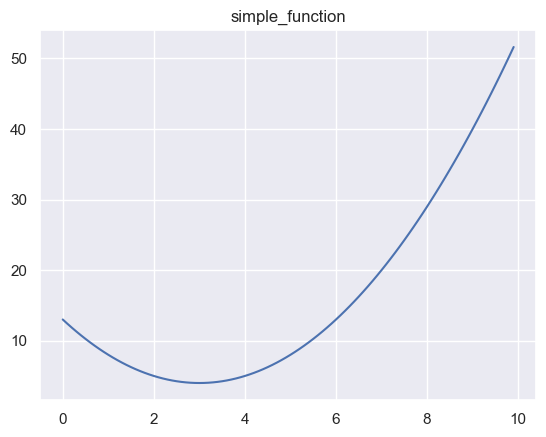

In [20]:
xs = np.arange(0, 10, 0.1)
ys = simple_function(xs)
plt.plot(xs, ys)
plt.title("simple_function")
plt.show()

![](sgdmomentum.png) 
Bild aus: https://www.willamette.edu/~gorr/classes/cs449/momrate.html

Die sogennante Lossfunktion, die bei neuronalen Netzen optimiert wird, hat im allgemeinen viele lokale Minima bzw. Sattelpunkte. Darüber hinaus wird meistens ein stochastischer Gradientenabstieg verwendet. Dabei wird der Gradient nicht bezüglich des ganzen Datensatzes berechnet, sondern lediglich bezüglich einer Teilmenge (dem sogennanten Batch). Insgesamt treten die folgenden Probleme auf:
* viele lokale Minima und Sattelpunkte
* kein exakter, sondern stochastischer Gradient
* extreme Sensibilität gegenüber der Schrittweite $\alpha$.

Deswegen wurden verschiedene Modifizierungen des einfachen Gradientenverfahrens entwickelt. Die bekannteste ist das sogenante Momentum-Verfahren. Dabei werden die vorherigen Gradienten gemittelt, sodass zufällige Effekte und Gradienten, die in unterschiedliche Richtungen zeigen (siehe Bild) gemittelt (und so deren Einflüsse reduziert) werden.

Sei $n\in\mathbb{N}$ wieder die zugrundeligende Dimension, $f:\mathbb{R}^n\rightarrow\mathbb{R}$ die zu optimierende Dimension und $x_0\in\mathbb{R}^n$ ein Startwert. 

Dann erzeugt das Momentum Verfahren zwei Folgen $(m_i)_{i\in\mathbb{N}}\subset\mathbb{R}^n$ und $(x_i)_{i\in\mathbb{N}}\subset\mathbb{R}^n$, wobei $(x_i)_{i\in\mathbb{N}}$ die Approximation der Lösung und $(m_i)_{i\in\mathbb{N}}\subset\mathbb{R}^n$ den gemittelten Gradienten darstellt. Sei weiter $\alpha > 0 $ die Schrittweite, $\gamma \in [0,1]$ ein Abklingfaktor und $m_0 = 0$. 

Dann ist das Momentumupdate für $i=1,\ldots$ gegeben durch:
$\begin{cases}
m_i = \gamma m_{i-1} + \alpha \nabla f(x_{i-1}) \\
x_i = x_{i-1} - m_i.
\end{cases}$

Das Momentumverfahren ist aber weiterhin sehr sensibel gegenüber der Schrittweite $\alpha$. Ein weiteres bekanntes Verfahren, das die Schrittweite teilweise automatisch skaliert und so weniger sensibel gegenüber der Schrittweite ist, ist das Adam-Verfahren.

Das Adam-Verfahren benutzt neben der gemittelten Gradienten auch die gemittelten zweiten Momente der Gradienten (also die quadrierten Gradienten) $\nabla f(x) \odot \nabla f(x)$. Es seien also drei Folgen $(m_i)_{i\in\mathbb{N}}\subset\mathbb{R}^n$, $(v_i)_{i\in\mathbb{N}}\subset\mathbb{R}^n$ und $(x_i)_{i\in\mathbb{N}}\subset\mathbb{R}^n$ mit $v_0=m_0=0$ sowie Abklingfaktoren $\beta_1,\beta_2\in[0,1]$, eine Schrittweite $\alpha > 0 $ und ein Regularisierungsterm $\epsilon >0$ gegeben. Dann sind die Updates des Adam-Verfahrens gegeben durch:
$\begin{cases}
m_i = \beta_1 m_{i-1} + (1-\beta_1) \nabla f(x_{i-1}) \\
v_i = \beta_2 v_{i-1} + (1-\beta_2) \left(\nabla f(x_{i-1})\odot \nabla f(x_{i-1})\right) \\
\hat{m}_i = \frac{m_i}{1- \beta_1^i} \\
\hat{v}_i = \frac{v_i}{1- \beta_2^i} \\
x_i = x_{i-1} - \alpha \frac{\hat{m}_i}{\sqrt{\hat{v}_i} + \epsilon}.
\end{cases}$

Hierbei dienen die beiden Terme $\hat{m}_i$ und $\hat{v}_i$ lediglich der Korrektur eines $0$-Biases (beide werden mit $0$ initialisiert und wären deswegen ohne die Korrektur insbesondere anfangs nahe bei $0$).

Durch die Skalierung mit den zweiten Momenten wird die Lerngeschwindigkeit in den einzelnen Dimensionen angepasst. Die Updates der Dimensionen, bei denen schon häufige Updates vorkommen, werden verringert, in Dimensionen, bei denen kaum Updates vorkamen (kleine quadrierten Gradienten), wird die Lerngeschwindigkeit erhöht.

In der Literatur findet man die Standardwerte $\beta_1 = 0.9$, $\beta_2 = 0.999$ und $\epsilon = 10^{-8}$.


Die obigen Gradientenverfahren haben wir in der Klasse `Optimizer` implementiert.

In [21]:
class Optimizer:
    
    def __init__(self, kind, parameters):
        self.kind = kind
        self.parameters = parameters
        
        #momentum
        self.m = 0
        
        # adam
        self.v = 0
        self.step = 1
        
    def update(self, current_gradient):
        if self.kind == "sgd":
            return self.parameters["alpha"] * current_gradient
        
        elif self.kind == "momentum":
            self.m = self.parameters["gamma"] * self.m + self.parameters["alpha"] * current_gradient
            return self.m
        
        elif self.kind == "adam":
            self.m = self.parameters["beta1"] * self.m + (1 - self.parameters["beta1"]) * current_gradient
            self.v = self.parameters["beta2"] * self.v + (1 - self.parameters["beta2"]) * (current_gradient ** 2)
            mhat = self.m / (1 - self.parameters["beta1"] ** self.step)
            vhat = self.v / (1 - self.parameters["beta2"] ** self.step)
            
            self.step += 1
            return self.parameters["alpha"] * mhat / (np.sqrt(vhat) + self.parameters["epsilon"])

## Aufgabe 4
* An welcher Stelle ist das Minimum von `simple_function`?
* Initialisiere eine Instanz des Momentumoptimizers mit dem Namen `momentum_optim` und den Parametern `{"alpha": 0.1, "gamma": 0.5}`.
* Teste `momentum_optim` durch den Aufruf der Funktion `iterate_for_(0, simple_function_gradient, 5, momentum_optim)`. Findet das Verfahren das Minimum?
* Plotte für $\alpha \in \{0.01, 0.1, 0.6, 0.9\}$ die ersten 30 Iterationen des einfachen Gradientenabstiegs für den Startwert 0 (siehe unten).
* Plotte für $\alpha \in \{0.01, 0.1, 0.6, 0.9\}$ und `gamma = 0.5` die ersten 30 Iterationen des Momentumoptimizers für den Startwert 0 (siehe unten).
* Plotte für $\alpha \in \{0.6, 1, 5, 10\}$ und `beta1 = 0.5, beta2 = 0.999, epsilon = 1e-8` die ersten 30 Iterationen des Adamoptimizers für den Startwert 0 (siehe unten).
* Vergleiche die Ergebnisse der drei unterschiedlichen Optimizer. Was fällt dir auf?

Tipp: Möglicherweise kannst du zum Plotten etwas der folgenden Art verwenden:
```python
plt.plot(iterate_for_(0, simple_function_gradient, 30, insert optimizer here), label="alpha: x")
# ...
plt.legend(loc="upper right")
plt.title("Plain SGD")
plt.show()
```

In [22]:
# Minimum simple_function

In [23]:
momentum_optim = Optimizer("momentum", {"alpha": 0.1, "gamma": 0.3})
results = iterate_for_(0, simple_function_gradient, 5, momentum_optim)
print("Momentum nach 5 Iterationen: ", results)

Momentum nach 5 Iterationen:  [0.6000000000000001, 1.2600000000000002, 1.8060000000000003, 2.2086, 2.48766]


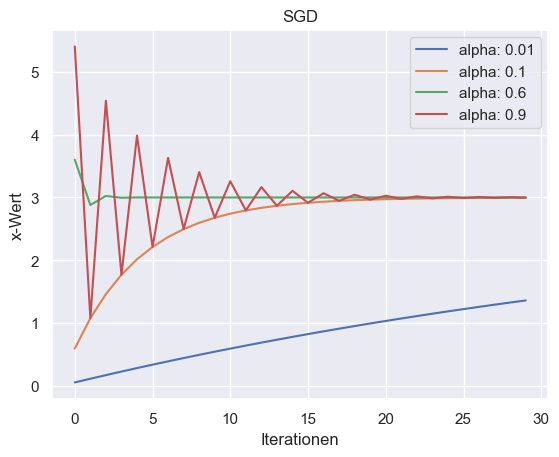

In [24]:
alphas = [0.01, 0.1, 0.6, 0.9]
for alpha in alphas:
    sgd_optimizer = Optimizer("sgd", {"alpha": alpha})
    approximations = iterate_for_(0, simple_function_gradient, 30, sgd_optimizer)
    plt.plot(approximations, label=f"alpha: {alpha}")
plt.legend()
plt.title("SGD")
plt.xlabel("Iterationen")
plt.ylabel("x-Wert")
plt.show()

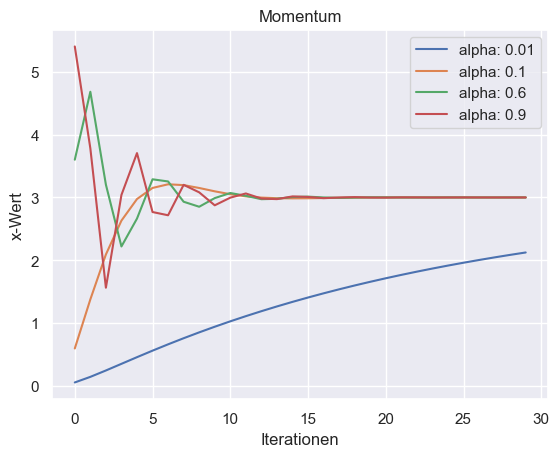

In [25]:
alphas = [0.01, 0.1, 0.6, 0.9]
for alpha in alphas:
    momentum_optimizer = Optimizer("momentum", {"alpha": alpha, "gamma": 0.5})
    approximations = iterate_for_(0, simple_function_gradient, 30, momentum_optimizer)
    plt.plot(approximations, label=f"alpha: {alpha}")
plt.legend()
plt.title("Momentum")
plt.xlabel("Iterationen")
plt.ylabel("x-Wert")
plt.show()

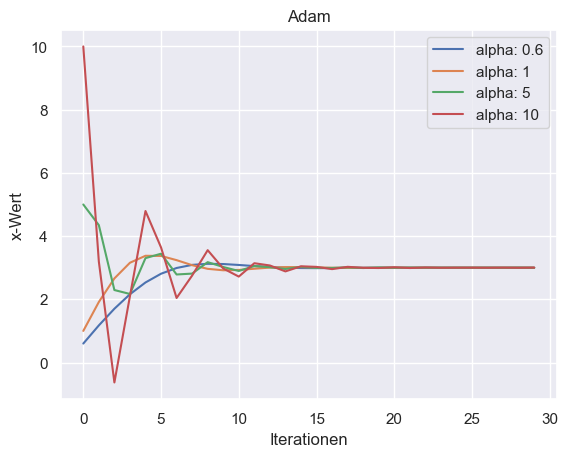

In [26]:
alphas = [0.6, 1, 5, 10]
for alpha in alphas:
    adam_optimizer = Optimizer("adam", {"alpha": alpha, "beta1": 0.5, "beta2": 0.999, "epsilon": 1e-8})
    approximations = iterate_for_(0, simple_function_gradient, 30, adam_optimizer)
    plt.plot(approximations, label=f"alpha: {alpha}")
plt.legend()
plt.title("Adam")
plt.xlabel("Iterationen")
plt.ylabel("x-Wert")
plt.show()

Textuelle Lösung von Aufgabe 4:

In [27]:
# SGD ungeignet für kleine alpha, braucht viele Iterationen. für zu große divergiert
#Schneller als SGD, ebenso ungeeignet für kleine alpha
#Adam am besten; kann mit großen Unterschieden in alphawert umgehen bzw. weniger sensibel

# Einführung in Keras
## Binäre Klassifikation
Zuerst generieren wir einen Testdatensatz mit sklearns `make_moons` und teilen diesen in Train/Test set auf.

<Axes: >

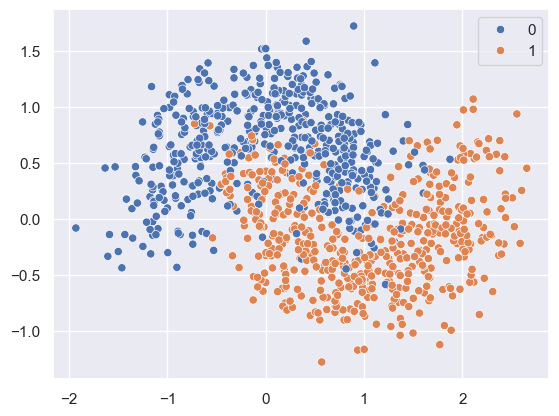

In [55]:
X, y = datasets.make_moons(n_samples=1000, random_state=2, noise=.3)
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y)

In [56]:
X.shape

(1000, 2)

In [57]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.33, random_state=2)

Ein neuronales Netz kann in Keras (was mittlerweile ein High-Level-Interface des Packages TensorFlow ist) über die Sequential-Klasse `tf.keras.Sequential` erstellt werden. Eine andere Option ist die direkte model-Verwendung, die zum Beispiel so aussehen kann, hier aber nicht verwendet werden soll:
```python
## Define neural network
input_layer = tf.keras.layers.Input(shape=(12,))
hidden_layer = tf.keras.layers.Dense(5, activation="tanh")(input_layer)
hidden_layer = tf.keras.layers.Dropout(0.3)(hidden_layer)
hidden_layer = tf.keras.layers.Dense(5, activation="tanh")(hidden_layer)
hidden_layer = tf.keras.layers.Dropout(0.3)(hidden_layer)
output_layer = tf.keras.layers.Dense(1, activation="sigmoid")(hidden_layer)

model = tf.keras.Model(input_layer, output_layer)
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()

```

In [58]:
#import tensorflow as tf

np.random.seed(42) #Kantengewichte eines NN werden zufällig initialisiert. Ein Seed stellt sicher, dass 
tf.random.set_seed(42) #bei der Initialisierung immer die gleichen (zufälligen) Zahlen herauskommen

In [59]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(3, activation="relu", input_shape=[2]),
tf.keras.layers.Dense(3, activation="relu")]) # Ebene mit drei Neuronen, die zweidimensionale Daten erhält. Aktivierungsfunktion relu


model.add(tf.keras.layers.Dense(1, activation="sigmoid")) # Ebene mit einem Neuron der Aktivierungsfunktion sigmoid ("Wahrscheinlichkeit")
# Hinzufügen einer Ebene geht über den Konstruktor oder model.add

/Users/alimounir/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [60]:
model.summary() # needs input_shape in first layer

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25 (100.00 B)

 Trainable params: 25 (100.00 B)

 Non-trainable params: 0 (0.00 B)

Bevor wir `model` trainieren können, müssen wir einmal `model.compile` aufrufen, um das Modell auf das Training vorzubereiten. Wir verwenden das Adam Gradientenverfahren mit einer Lerngeschwindigkeit von $10^{-2}$ und den `binary_crossentropy` loss.

In [61]:
# Compile with adam optimizer
adam = tf.keras.optimizers.Adam(learning_rate=1e-2)
model.compile(optimizer=adam, loss="binary_crossentropy", metrics=["accuracy"])

Anschließend können wir das Modell trainieren. Die Gradienten bezüglich des Trainingsfehlers werden dabei automatisch von TensorFlow mittels Backpropagation berechnet. Wir verwenden eine Batchgröße des stochastischen Gradientenabstiegs von $32$ und lassen den Algorithmus $20$ Epochen laufen. Eine Epoche ist ein Durchlauf über den gesamten Trainingsdatensatz. Nach jeder Epoche wird der aktuelle Loss und die Accuracy angezeigt.

In [62]:
X_train.shape

(670, 2)

In [63]:
y_train.shape

(670,)

In [64]:
# Fit model
model.fit(X_train, y_train, batch_size=32, epochs=20)

Epoch 1/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5216 - loss: 0.7223   
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7119 - loss: 0.5622 
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7479 - loss: 0.5132 
Epoch 4/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7828 - loss: 0.4765 
Epoch 5/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8087 - loss: 0.4466 
Epoch 6/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8323 - loss: 0.4237 
Epoch 7/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8346 - loss: 0.4070 
Epoch 8/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8353 - loss: 0.3958 
Epoch 9/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8387 - loss: 0.3868 
Epoch 10/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8368 - loss: 0.3808 
Epoch 11/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8469 - loss: 0.3750 
Epoch 12/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy

Nach dem Training können wir das Modell auf dem Testdatensatz testen und mit `model.predict` das neuronale Netz auf neue Datenpunkte anwenden.

In [65]:
model.evaluate(X_test, y_test) # evaluate on test dateset

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8797 - loss: 0.3058  


[0.30036091804504395, 0.8878787755966187]

In [66]:
model.predict(np.array([[0, 0]])) # neuen Wert vorhersagen

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


array([[0.66679436]], dtype=float32)

Schlussendlich können wir noch die Entscheidungsgrenze visualisieren.

In [67]:
grid_size = 3
g_min, g_max = -grid_size, grid_size
xx, yy = np.meshgrid(np.arange(g_min, g_max, 0.1), np.arange(g_min, g_max, 0.1))
Z = model.predict(tf.convert_to_tensor(np.c_[xx.ravel(), yy.ravel()]))
Z = Z.reshape(xx.shape)

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 993us/step


<Axes: >

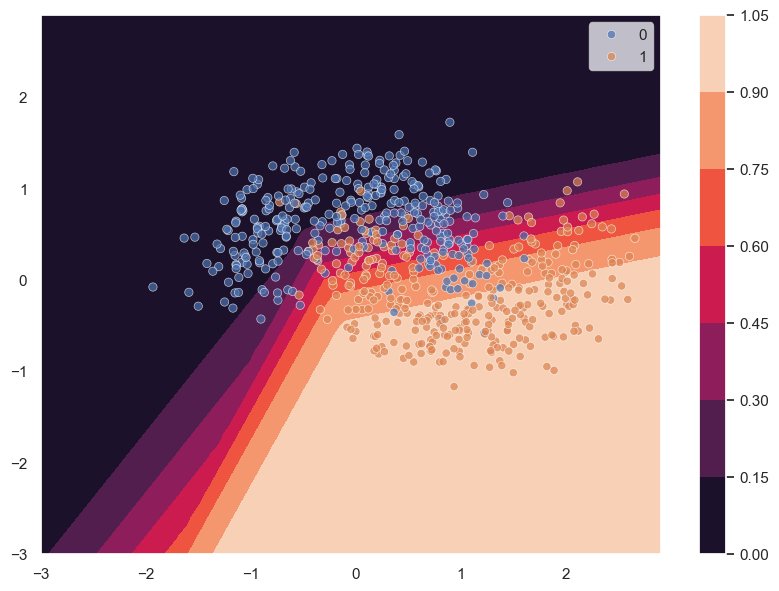

In [68]:
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z)
plt.colorbar()
sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1], hue=y_train, alpha=.7)

## Aufgabe 5 (Kein Code, nur schriftliche Ausformulierung):
* Betrachte die obige Visualisierung. Kann das sehr einfache neuronale Netz den Datensatz gut approximieren? Lässt sich das anhand der accuracy erkennen?
* Wie könnte eine bessere Separierung durch das NN erreicht werden?

Lösung Aufgabe 5:


Die schlechte Separierung deutet darauf hin, dass das aktuelle Modell eine zu geringe Modellkapazität hat, um die nicht-lineare Beziehung zwischen den Features korrekt abzubilden.

Eine bessere Separierung und damit eine höhere Genauigkeit könnte durch folgende Maßnahmen erreicht werden: Hinzufügen von Layern (Tiefe), Erhöhen der Neuronenanzahl (Breite), Verwendung geeigneterer Aktivierungsfunktionen

## Klassifikation mit mehreren Klassen
Als nächstes versuchen wir uns an der Klassifikation im Falle von mehr als zwei Klassen.

In [75]:
X, y = datasets.make_blobs(n_samples=1000, random_state=2, centers=9, cluster_std=1.2)

In [76]:
y[(y % 3) == 0] = 0 # datensatz mit drei Klassen erstellen
y[(y % 3) == 1] = 1
y[(y % 3) == 2] = 2

<Axes: >

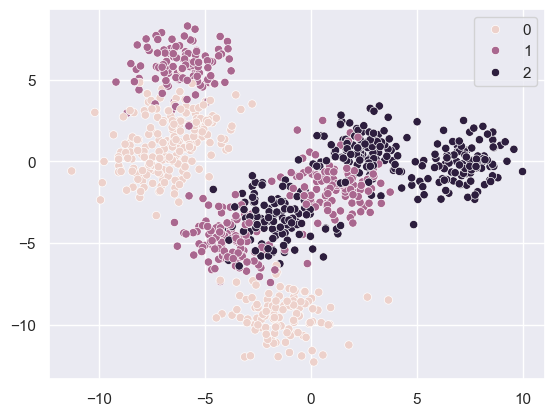

In [77]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y)

In [78]:
ohe = preprocessing.OneHotEncoder(categories="auto", sparse_output=False) # one hot encoding (Eine 1 im i-ten Eintrag entspricht Klasse i)
y_one_hot = ohe.fit_transform(y.reshape(-1, 1))
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y_one_hot, test_size=0.33, random_state=2)

## Aufgabe 6:
a)
* Verwende ein neuronales Netz zur Klassifikation des obigen Datensatzes. Modifiziere das Training oder den Algorithmus so lange, bis du eine Test accuracy von $\approx 87\%$ erhältst!
* Visualisiere die Entscheidungsgrenze wie im vorherigen Beispiel. Kann das neuronale Netz die Nichtlinearität des Datensatzes besser approximieren als im vorherigen Beispiel?

Tipps: 
* Falls du Schwierigkeiten hast, ein neuronales Netz zu erstellen, schaue dir das Code-Beispiel oben an.
* Wir Betreuer konnten mit drei verdeckten Schichten ganz gute Ergebnisse erzielen :)
* Modifiziere den Visualisierungscode des obigen Beispiels für Multiklassenklassifikation mittels `np.argmax`, um so vom One Hot Encoding zurück auf eindimensionale Labels zu kommen.


In [79]:
np.random.seed(42)
tf.random.set_seed(42)

In [80]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(3, activation="softmax")
])
#
adam = tf.keras.optimizers.Adam(learning_rate=0.01)
model.compile(optimizer=adam, loss="categorical_crossentropy", metrics=["accuracy"])

/Users/alimounir/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [81]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,531 (25.51 KB)

 Trainable params: 6,531 (25.51 KB)

 Non-trainable params: 0 (0.00 B)

In [82]:
history = model.fit(X_train, y_train, batch_size=32, epochs=50, validation_split=0.2)

Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6075 - loss: 0.8346 - val_accuracy: 0.8134 - val_loss: 0.4839
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7728 - loss: 0.4794 - val_accuracy: 0.8209 - val_loss: 0.4494
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8128 - loss: 0.4097 - val_accuracy: 0.8358 - val_loss: 0.4122
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8370 - loss: 0.3540 - val_accuracy: 0.8582 - val_loss: 0.4124
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8558 - loss: 0.3394 - val_accuracy: 0.8806 - val_loss: 0.3716
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8682 - loss: 0.3090 - val_accuracy: 0.8731 - val_loss: 0.3815
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8771 - loss: 0.3049 - val_accuracy: 0.8881 - val_loss: 0.3370
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8796 - loss: 0.2828 - val_accuracy: 0.8433 - val_loss

In [83]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss:.4f}, test Accuracy: {test_accuracy:.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8702 - loss: 0.2695 
Test Loss: 0.2622, test Accuracy: 0.8788


1646/1646 ━━━━━━━━━━━━━━━━━━━━ 1s 618us/step


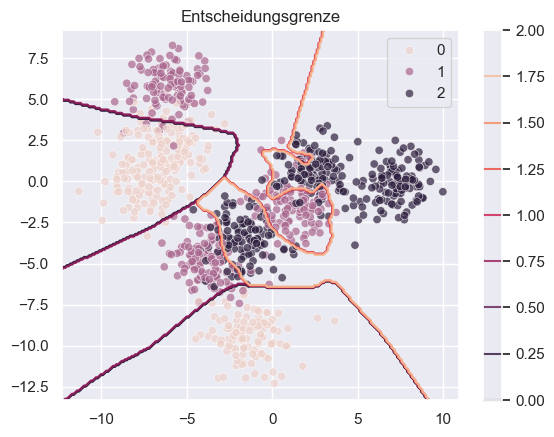

In [84]:
grid_size = 0.1
x_min, x_max = X[:,0].min() - 1, X[:,0].max() +1
y_min, y_max = X[:,1].min() - 1, X[:,1].max() +1

xx, yy = np.meshgrid(np.arange(x_min, x_max, grid_size), np.arange(y_min, y_max, grid_size))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = np.argmax(Z, axis=1)
Z = Z.reshape(xx.shape)

plt.figure()
plt.contour(xx, yy, Z, alpha=0.8)
plt.colorbar()
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y, alpha=0.7)
plt.title("Entscheidungsgrenze")
plt.show()

In [85]:
#Ja das Netz kann besser mit der nichtlinearität der Daten umgehen, weil es mehr Schichten hat.

b) Berechne und plotte die Confusion-Matrix. (Tipp: Verwende die in sklearn eingebaut Funktion, zur Berechnung der Confusion Matrix)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


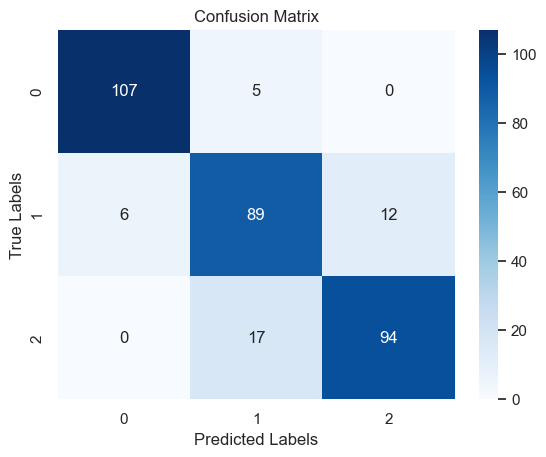

In [86]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

c) Berechne die Accuracy, die Precision und den Recall für die Klasse 2. Bestimme hierfür zunächst die True Positive (TP), True Negative (TN), False Positve (FP) und False Negative (FN) Werte für die Klasse 2 mit Hilfe der Confusion Matrix.

In [87]:
class_label = 2

TP = cm[class_label, class_label]
FP = cm[:,class_label].sum()-TP
FN = cm[class_label, :].sum()-TP
TN = cm.sum() - (TP + FP + FN)

accuracy = (TP+TN)/ cm.sum()
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0

print(f"True Positives (TP): {TP}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"True Negatives (TN): {TN}")

print(f"Accuracy : {accuracy:.2f}")
print(f"Precision : {precision:.2f}")
print(f"Recall : {recall:.2f}")

True Positives (TP): 94
False Positives (FP): 12
False Negatives (FN): 17
True Negatives (TN): 207
Accuracy : 0.91
Precision : 0.89
Recall : 0.85


## Regression

In [88]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.boston_housing.load_data()

## Aufgabe 7 (freiwillig):
* Trainiere ein neuronales Netz zur Regression auf dem bekannten obigen Datensatz. Erreiche möglichst einen MSE von $MSE < 25$ auf dem Test-Datensatz

In [89]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

In [94]:
df_clean = df.dropna(subset=['Age']).copy()
df_clean.drop(columns=['PassengerId'], inplace=True, errors='ignore')

X = df_clean.drop('Age', axis=1).values
Y = df_clean['Age'].values

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

NameError: name 'df' is not defined

In [92]:
def create_regression_model(input_shape):

    model = keras.Sequential([
        # 1. Hidden Layer
        keras.layers.Dense(64, activation='relu', input_shape=(input_shape,)),
        
        # 2. Hidden Layer (Mehr Tiefe)
        keras.layers.Dense(32, activation='relu'),
        
        # 3. Hidden Layer
        keras.layers.Dense(16, activation='relu'),
        
        # Output Layer: 1 Neuron, Lineare Aktivierung (Regression)
        keras.layers.Dense(1, activation='linear')
    ])

    # Kompilierung für Regression
    model.compile(optimizer='adam',
                  loss='mse',
                  metrics=['mse', 'mae'])
    return model

In [93]:
input_dim = X_train_scaled.shape[1]
model = create_regression_model(input_dim)
model.summary()

NameError: name 'X_train_scaled' is not defined

In [ ]:

# --- Training (Hypothetisch) ---
# history = model.fit(X_train_scaled, Y_train, epochs=150, batch_size=32, validation_split=0.1, verbose=0)

# --- Auswertung (Hypothetisch) ---
# results = model.evaluate(X_test_scaled, Y_test, verbose=0)
# final_mse = results[0]
# print(f"\nErreichtes MSE auf dem Test-Datensatz: {final_mse:.2f}")

# Wichtig: Ein MSE < 25 bedeutet, dass die vorhergesagten Alterswerte
# im Durchschnitt nur ca. sqrt(25) = 5 Jahre vom tatsächlichen Alter abweichen.